<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°2 de TPS: Regresión Polinómica

## Ítem A

### Punto 1


Preparación del entorno de programación.

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer

Carga de la base de datos y comprobación de los mismos.

In [47]:
# Cargar la base de datos
df = sns.load_dataset('healthexp')
df

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


### Punto 2

A partir de estos datos extraídos, se analiza la relación entre el gasto público en salud per cápita y la esperanza de vida mediante un gráfico de dispersión. Cada punto representa un país en un determinado año, y se utiliza un color distinto para identificar a cada uno.

El objetivo es observar posibles patrones o correlaciones entre ambas variables, y comparar cómo se comportan los distintos países.

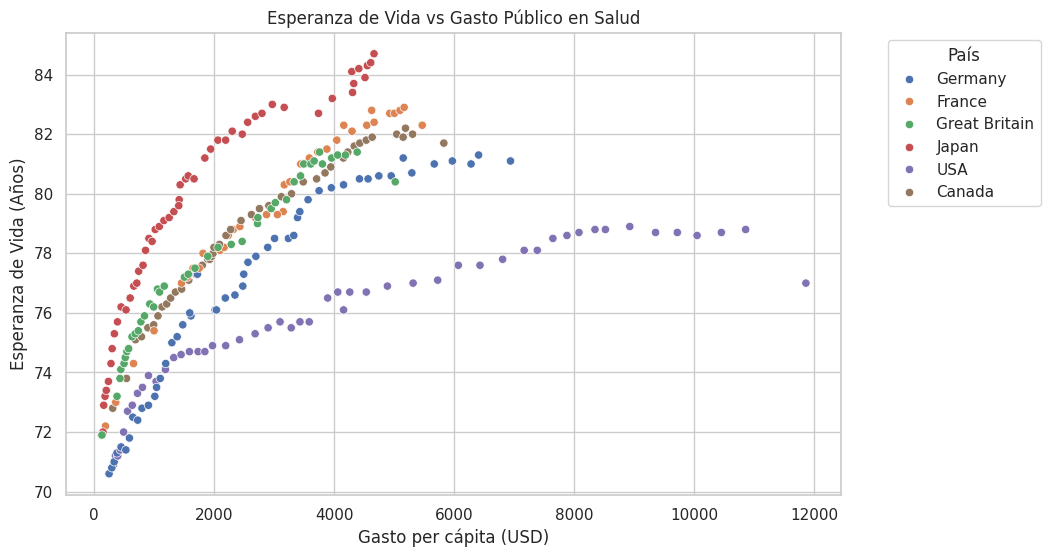

In [48]:
# Graficar scatter de esperanza de vida vs gasto público por país
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Spending_USD', y='Life_Expectancy', hue='Country')
plt.title('Esperanza de Vida vs Gasto Público en Salud')
plt.xlabel('Gasto per cápita (USD)')
plt.ylabel('Esperanza de Vida (Años)')
plt.grid(True)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


A partir del gráfico se observa una relación creciente entre el gasto público en salud per cápita y la expectativa de vida. En términos generales, mayores niveles de gasto se asocian con mayores valores de longevidad.

Sin embargo, esta relación no es lineal. Para niveles bajos e intermedios de gasto, los incrementos generan mejoras relativamente significativas en la expectativa de vida. En cambio, a partir de aproximadamente 2008, varias curvas comienzan a aplanarse. Se observa que aumentos adicionales en el gasto se traducen en mejoras cada vez menores.

En los últimos años de la serie también se aprecia que, salvo en Japón, varios países incrementan su gasto mientras que la expectativa de vida se estanca o incluso disminuye levemente. Este comportamiento, particularmente visible en el último año de cada país, podría explicarse por el impacto de la pandemia de COVID-19, que habría elevado el gasto sanitario mientras aumentaba la mortalidad.

Por último, se evidencian diferencias entre países para niveles similares de gasto. En particular, Estados Unidos presenta niveles considerablemente más altos sin alcanzar las mayores expectativas de vida, mientras que Japón logra mejores resultados con menor gasto, lo que indica que la longevidad depende también de factores estructurales más allá de la inversión en salud.

### Punto 3

Los datos se dividieron en conjuntos de entrenamiento, validación y testeo utilizando un criterio temporal. A lo largo de este trabajo práctico, se entrenará al modelo con observaciones anteriores a 2008, se lo validará con los datos entre 2008 y 2015, y se evaluará su desempeño final con datos posteriores a 2015. Esta partición permite simular un escenario más realista, en el cual el modelo aprende a partir del pasado y se evalúa sobre años futuros.

In [49]:
# Definir conjuntos de entrenamiento, validación y testeo
# Entrenamiento: anterior al 2008
train_df = df[df['Year'] < 2008]

# Validación: entre 2008 y 2015 (inclusive)
val_df = df[(df['Year'] >= 2008) & (df['Year'] <= 2015)]

# Testeo: posteriores al 2015
test_df = df[df['Year'] > 2015]

# ¿Es necesario?
print(f"Registros - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Registros - Train: 196, Val: 48, Test: 30


## Ítem B

En este apartado se preparan los datos antes de entrenar el modelo. La idea es transformar las variables originales a una forma que el algoritmo pueda usar correctamente. En particular, se trabaja por un lado con la variable categórica `Country`, que debe convertirse en variables numéricas, y por otro lado con la variable de gasto, sobre la cual se busca construir una representación que permita capturar relaciones no lineales.

### Punto 1

La variable `Country` indica a qué país pertenece cada dato, pero como es una variable categórica, no se la puede usar directamente como un número. Por ejemplo, no tendría sentido decir que Japón vale 1, USA vale 2 y Alemania vale 3, porque eso haría parecer que hay un orden entre países, cuando en realidad no lo hay.

Para resolver esto se usa `OneHotEncoder`, que transforma cada país en una variable binaria. Es decir, para cada país se crea una columna que vale 1 si el dato pertenece a ese país y 0 si no pertenece.

Si hay \(K\) países distintos, entonces se generan \(K\) variables indicadoras. De esta forma, el modelo puede distinguir de qué país viene cada observación sin inventar relaciones de orden que no existen.

En este trabajo, esta transformación es útil porque en el gráfico se ve que, para niveles parecidos de gasto público en salud, no todos los países tienen exactamente la misma esperanza de vida. Entonces, codificar el país de esta manera permite que el modelo tenga en cuenta esas diferencias.

In [50]:
# Se define el codificador
encoder = OneHotEncoder(sparse_output=False) # sparse_output=False para ver la matriz fácilmente

# Ejemplo de funcionamiento (opcional para ver qué hace):
paises_encoded = encoder.fit_transform(train_df[['Country']])
nombres_columnas = encoder.get_feature_names_out(['Country'])

print("Nuevas columnas creadas:", nombres_columnas)
print("Ejemplo de las primeras filas:\n", paises_encoded[:5])

Nuevas columnas creadas: ['Country_Canada' 'Country_France' 'Country_Germany'
 'Country_Great Britain' 'Country_Japan' 'Country_USA']
Ejemplo de las primeras filas:
 [[0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]


### Punto 2

Sobre la variable `Spending_USD` se aplica una transformación polinómica de grado 3, generando las variables ($x$), ($x^2$) y ($x^3$). Esta elección busca darle al modelo la posibilidad de ajustarse a una relación curva entre el gasto público en salud y la esperanza de vida.

Esto resulta razonable a partir del análisis gráfico, donde se observa que la relación entre ambas variables no sigue una recta: para ciertos rangos de gasto la esperanza de vida crece con mayor intensidad, mientras que en otros la tendencia se va aplanando. En consecuencia, trabajar solamente con la variable original sería demasiado restrictivo, mientras que incorporar términos de segundo y tercer grado permite representar mejor esa forma.

De esta manera, el grado 3 aparece como una elección intermedia: suficientemente flexible para capturar la curvatura observada, pero sin introducir una complejidad demasiado alta. Además, esta elección coincide con lo indicado en el enunciado del trabajo práctico.

In [51]:
# Se define el generador de características polinómicas de grado 3
# include_bias=False porque el bias lo suele manejar el modelo de regresión después
poly = PolynomialFeatures(degree=3, include_bias=False)

# Ejemplo de funcionamiento:
gasto_poly = poly.fit_transform(train_df[['Spending_USD']])
print("Primeras filas con [x, x^2, x^3]:\n", gasto_poly[:5])

Primeras filas con [x, x^2, x^3]:
 [[2.52311000e+02 6.36608407e+04 1.60623304e+07]
 [1.92143000e+02 3.69189324e+04 7.09371444e+06]
 [1.23993000e+02 1.53742640e+04 1.90630112e+06]
 [1.50437000e+02 2.26312910e+04 3.40458352e+06]
 [3.26961000e+02 1.06903496e+05 3.49532738e+07]]


### Punto 3

En este paso se juntan las transformaciones hechas sobre cada variable de entrada. Por un lado, la variable `Country` se convierte en \(K\) columnas binarias, donde \(K\) es la cantidad de países distintos. Por otro lado, la variable `Spending_USD` se reemplaza por tres columnas: \($x$\), \($x^2$\) y \($x^3$\).

De esta manera, cada observación deja de estar representada por solo dos datos originales y pasa a describirse mediante un vector de \(K+3\) componentes. Las primeras \(K\) posiciones indican el país, y las tres restantes contienen la información del gasto y sus potencias.

Luego, sobre esa nueva matriz se aplica una normalización, restando la media y dividiendo por el desvío estándar. Esto no cambia el significado de las variables, sino que las lleva a una escala comparable. La idea es evitar que algunas columnas dominen a las demás solo por tener valores numéricamente más grandes.

In [52]:
# 1. Combinar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Country']),
        ('poly', PolynomialFeatures(degree=3, include_bias=False), ['Spending_USD'])
    ]
)

# 2. Se aplica la transformación y luego se normaliza
# Nota: fit_transform solo se hace sobre TRAIN. Para VAL y TEST se usa transform.
X_train_raw = train_df[['Country', 'Spending_USD']]
X_train_combined = preprocessor.fit_transform(X_train_raw)

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_combined)

print("Forma final de la matriz de entrenamiento:", X_train_final.shape)
print("Los datos ahora están normalizados (media ~0 y varianza ~1)")

Forma final de la matriz de entrenamiento: (196, 9)
Los datos ahora están normalizados (media ~0 y varianza ~1)


## Ítem C

En este punto se arma el modelo completo. Es decir, se toman las variables originales (`Country` y `Spending_USD`), se les aplican las transformaciones del ítem B y, con eso, se entrena un modelo para predecir la esperanza de vida.

La idea es simple: el país se usa para distinguir diferencias entre países, y el gasto público en salud se usa en forma polinómica para que el modelo no quede limitado a una recta. Así, el sistema puede ajustarse mejor a la forma que muestran los datos.

Una vez armado el modelo, se lo entrena con el conjunto de entrenamiento, se evalúa qué tan bien funciona sobre entrenamiento y validación, y después se grafica el ajuste obtenido para cada país.

### Puntos 1 y 3


En este punto se arma el modelo completo como una secuencia de pasos. Primero se aplica el preprocesamiento de las variables, después la normalización y al final la regresión.

También se muestra el diagrama del sistema, para ver de manera más clara cómo está organizado el modelo.

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn import set_config

# c.1: Crear el Pipeline
# Combinamos el preprocesador (del ítem B) con la Regresión Lineal
model_pipeline = Pipeline([
    ('preprocessor', preprocessor), # El que definimos en el punto B
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()) # Recomendado por el TP
])

# c.3: Diagrama del sistema
set_config(display="diagram")
model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Country']),
                                                 ('poly',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['Spending_USD'])])),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

### Punto 2


In [54]:
X_train = train_df[['Country', 'Spending_USD']]
y_train = train_df['Life_Expectancy']

X_val = val_df[['Country', 'Spending_USD']]
y_val = val_df['Life_Expectancy']

X_test = test_df[['Country', 'Spending_USD']]
y_test = test_df['Life_Expectancy']

print("Variables X e y definidas correctamente.")

Variables X e y definidas correctamente.


In [55]:
# Para contar parámetros se necesita que el preprocesador vea los datos
preprocessor.fit(X_train)
n_paises = len(preprocessor.transformers_[0][1].get_feature_names_out())
n_poly = 3 # x^1, x^2, x^3

print(f"Parámetros por países (OneHot): {n_paises}")
print(f"Parámetros por gasto (Polinomio): {n_poly}")
print(f"Total de coeficientes (w): {n_paises + n_poly}")
print(f"Intersección (bias/b): 1")
print(f"Total de parámetros del modelo: {n_paises + n_poly + 1}")

Parámetros por países (OneHot): 6
Parámetros por gasto (Polinomio): 3
Total de coeficientes (w): 9
Intersección (bias/b): 1
Total de parámetros del modelo: 10


Luego del preprocesamiento, cada dato deja de estar representado solo por `Country` y `Spending_USD`, y pasa a describirse mediante 9 variables, cómo se observa en la celda de código arriba. De ellas, 6 corresponden a la codificación del país y 3 a la transformación polinómica del gasto: \($x$\), \($x^2$\) y \($x^3$\).

La cantidad de parámetros del modelo sale directamente de las variables que aparecen después del preprocesamiento. En este caso, el número 6 aparece porque en el conjunto de entrenamiento hay 6 países distintos. Como la variable `Country` se codifica con one-hot, se genera una columna por cada país. Por eso aparecen 6 variables asociadas al país.

El número 3 aparece porque sobre la variable `Spending_USD` se aplica una transformación polinómica de grado 3. Eso significa que, en lugar de usar solo la variable original, el modelo trabaja con tres columnas. Por eso hay 3 variables asociadas al gasto.

Por último, aparece el número 1 porque la regresión lineal incluye un término independiente, también llamado intercepto o bias. Ese término sirve como valor de base del modelo, es decir, un punto de partida a partir del cual después se suman los aportes de las demás variables.

Entonces, el total se entiende como:

$
6 \text{ (países)} + 3 \text{ (términos del polinomio)} + 1 \text{ (bias)} = 10
$

En otras palabras, el modelo tiene un parámetro por cada columna de entrada generada, más un parámetro extra que actúa como término base.



Con estas variables, el modelo construye la salida estimada \($\hat y$\) como una suma de aportes: un término independiente, más un peso para cada país, más un peso para cada uno de los términos del polinomio. En forma esquemática:

$
\hat y = b + w_1c_1 + w_2c_2 + \dots + w_6c_6 + w_7x + w_8x^2 + w_9x^3
$

Así, aunque el modelo se ajusta como una combinación lineal de variables, puede representar una relación polinómica entre el gasto público en salud y la esperanza de vida.

### Puntos 4 y 5

En este paso se entrena el modelo usando el conjunto de entrenamiento. Es decir, a partir de los datos anteriores a 2008, el sistema ajusta sus parámetros para poder predecir la esperanza de vida.

Una vez entrenado, se generan predicciones tanto sobre el conjunto de entrenamiento como sobre el conjunto de validación (los datos entre 2008 y 2015). Luego, se calcula el error cuadrático medio (MSE) en ambos casos, con el objetivo de comparar qué tan bien ajusta el modelo los datos con los que aprendió y qué tan bien se comporta sobre datos no vistos durante el entrenamiento.

In [56]:
from sklearn.metrics import mean_squared_error

# c.4: Entrenar el sistema
model_pipeline.fit(X_train, y_train)

# c.5: Reportar error cuadrático medio (MSE)
train_preds = model_pipeline.predict(X_train)
val_preds = model_pipeline.predict(X_val)

mse_train = mean_squared_error(y_train, train_preds)
mse_val = mean_squared_error(y_val, val_preds)

print(f"MSE Entrenamiento: {mse_train:.4f}")
print(f"MSE Validación: {mse_val:.4f}")

MSE Entrenamiento: 0.4265
MSE Validación: 5.3687


Los resultados muestran que el error sobre entrenamiento es mucho menor que el error sobre validación:

$
MSE_{train} = 0.4265
\qquad\qquad
MSE_{val} = 5.3687
$

Esto indica que el modelo logra ajustarse bien a los datos con los que fue entrenado, pero pierde precisión cuando se lo evalúa sobre datos más recientes.

Una posible explicación es que la relación entre gasto público en salud y esperanza de vida no se mantiene igual a lo largo de todo el período. En particular, a partir de 2008 varias trayectorias comienzan a aplanarse (cómo  se había comentado en el punto 3 del ítem A), por lo que un modelo entrenado con años anteriores puede no representar tan bien ese comportamiento.

En otras palabras, el modelo aprende bien la tendencia del conjunto de entrenamiento, pero generaliza peor sobre el conjunto de validación.

### Punto 6

En este paso se grafica la regresión aprendida por el modelo para cada país. Para eso, se generan distintos valores de gasto público en salud dentro del rango de los datos y, para cada país, se calcula la esperanza de vida predicha por el modelo.

Luego, esas curvas se superponen con los datos originales. Esto permite comparar visualmente el ajuste del modelo y ver si las predicciones siguen una forma razonable para cada país.

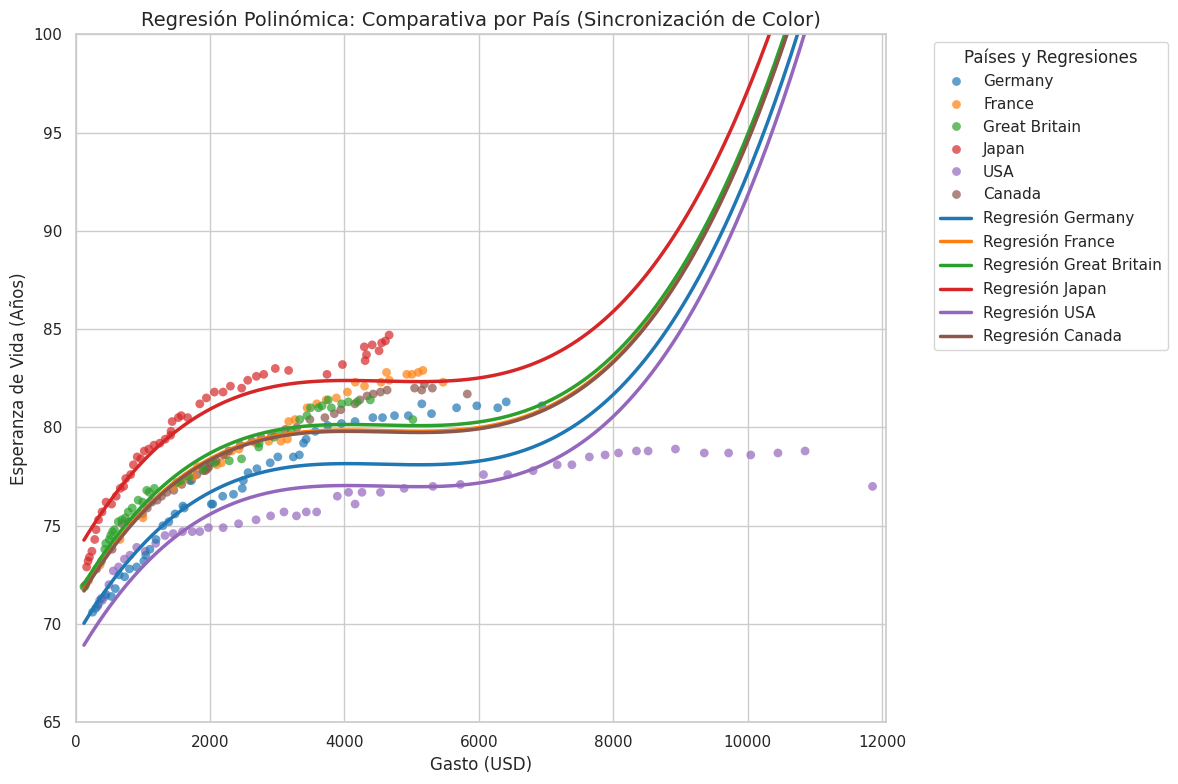

In [57]:
import numpy as np

# Seteamos un estilo y una paleta con más contraste
sns.set_theme(style="whitegrid")
palette = sns.color_palette("tab10", n_colors=len(df['Country'].unique()))

plt.figure(figsize=(12, 8))

# 1. Graficamos los datos reales con más presencia (alpha=0.7)
sns.scatterplot(
    data=df,
    x='Spending_USD',
    y='Life_Expectancy',
    hue='Country',
    palette=palette,
    s=40,      # Tamaño de punto un poco más grande
    alpha=0.7, # Más opacidad para que se vea el color real
    edgecolor='none'
)

# 2. Generamos la predicción
gasto_max = df['Spending_USD'].max()
gasto_range = np.linspace(df['Spending_USD'].min(), gasto_max, 300)
paises = df['Country'].unique()

# Dibujamos las líneas usando el mismo color de la paleta
for i, pais in enumerate(paises):
    X_plot = pd.DataFrame({'Country': [pais] * 300, 'Spending_USD': gasto_range})
    y_plot = model_pipeline.predict(X_plot)

    plt.plot(
        gasto_range,
        y_plot,
        color=palette[i],
        linewidth=2.5,
        label=f'Regresión {pais}'
    )

# 3. Ajustes de visualización
plt.ylim(65, 100)
plt.xlim(0, gasto_max + 200)

plt.title('Regresión Polinómica: Comparativa por País (Sincronización de Color)', fontsize=14)
plt.xlabel('Gasto (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)

# Movemos la leyenda para que no tape nada
plt.legend(title='Países y Regresiones', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Se observa que, en general, el modelo logra seguir la tendencia creciente de la esperanza de vida para valores bajos e intermedios de gasto (son los datos con los que el algoritmo fue entrenado). Por otro lado, cómo era esperado, las curvas generadas por el modelo, son polinomios de grado 3.

Sin embargo, el gráfico también deja ver una limitación fuerte del modelo. Para valores altos de gasto, varias curvas se disparan hacia arriba y llegan a predecir esperanzas de vida superiores a 100 años. Eso ya marca que el ajuste, en esa zona, dejó de ser realista. Los datos reales no muestran algo parecido a ese crecimiento, sino más bien un estancamiento.

La razón más probable es que el modelo está extrapolando (busca predecir en una zona donde casi no hay datos que lo guíen) con un polinomio de grado 3 en una región donde tiene poca información real. Mientras hay datos cerca, la curva todavía sigue una forma razonable. Pero cuando se aleja de esa zona, el polinomio empieza a crecer por la forma que tiene, no porque los datos indiquen que eso deba ocurrir. Es decir, la curva empieza a obedecer más a la matemática del modelo que al comportamiento real del fenómeno.

Visto así, el gráfico ayuda a entender mejor los errores obtenidos antes. El modelo ajusta bastante bien el conjunto de entrenamiento, pero al pasar a regiones más nuevas o más extremas pierde confiabilidad. Por eso no alcanza con que el error en entrenamiento sea bajo: también hace falta mirar si la forma de la regresión tiene sentido cuando se compara con los datos reales.

El desarrollo de este ítem muestra que no alcanza con entrenar un modelo y observar que funciona bien sobre los datos de entrenamiento. También es necesario evaluarlo sobre un conjunto de validación, ya que eso permite ver si realmente generaliza bien o si aparecen problemas que no se notaban al entrenarlo.

En este caso, si bien el modelo logra un error bajo sobre los datos de entrenamiento, al pasar al conjunto de validación el error aumenta de forma considerable. Además, al observar las curvas obtenidas, se ve que para ciertos rangos de gasto las predicciones dejan de resultar razonables. Esto indica que el modelo todavía no está capturando del todo bien el comportamiento de los datos.

Por lo tanto, el conjunto de validación cumple un rol importante: detectar si el modelo cumple con lo que se busca de él o necesita ser ajustado. En este trabajo, justamente permitió ver que el sistema todavía puede mejorarse, lo que da lugar a continuar ese análisis en el siguiente ítem.

## Ítem D

En este punto se intentará mejorar el modelo anterior usando regularización. La idea es seguir trabajando con el mismo modelo, pero agregando un control para que no ajuste de forma tan extrema.

Para eso se usa Ridge y se prueban distintos valores de $(\lambda)$. Luego se compara el error en entrenamiento y validación para elegir la opción que mejor generaliza.

### Puntos 1 y 2

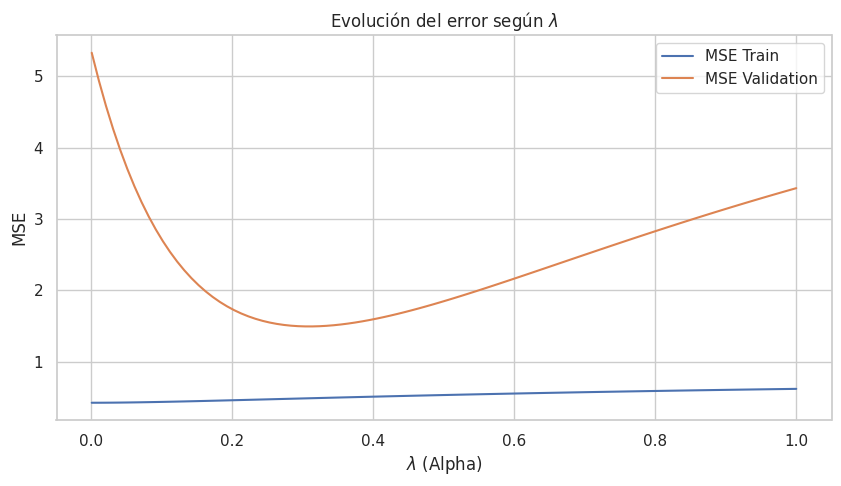

In [61]:
from sklearn.linear_model import Ridge
import numpy as np

# d.1: Probar diferentes valores de 0 < lambda < 1
lambdas = np.linspace(0.001, 1, 100)
train_errors = []
val_errors = []

for l in lambdas:
    # Creamos el pipeline con Ridge en lugar de LinearRegression
    ridge_model = Pipeline([
        ('prep', preprocessor),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=l)) # alpha es lambda en sklearn
    ])

    ridge_model.fit(X_train, y_train)

    # d.2: Calcular errores para graficar
    train_errors.append(mean_squared_error(y_train, ridge_model.predict(X_train)))
    val_errors.append(mean_squared_error(y_val, ridge_model.predict(X_val)))

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(lambdas, train_errors, label='MSE Train')
plt.plot(lambdas, val_errors, label='MSE Validation')
plt.title(r'Evolución del error según $\lambda$')
plt.xlabel(r'$\lambda$ (Alpha)')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

### Puntos 3 y 4

In [59]:
# 3. Reportar el lambda que minimiza el error de validación
best_lambda = lambdas[np.argmin(val_errors)]
print(f"El mejor lambda es: {best_lambda:.4f}")

# 4. Entrenar el modelo final con ese lambda y evaluar en TEST
final_model = Pipeline([
    ('prep', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_lambda))
])
final_model.fit(X_train, y_train)

test_preds = final_model.predict(X_test)
mse_test = mean_squared_error(y_test, test_preds)
print(f"MSE en el conjunto de Testeo: {mse_test:.4f}")

El mejor lambda es: 0.3138
MSE en el conjunto de Testeo: 5.2837


### Punto 5

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5269/643686964.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Regresión Ridge Final ($\lambda$={best_lambda:.4f})')


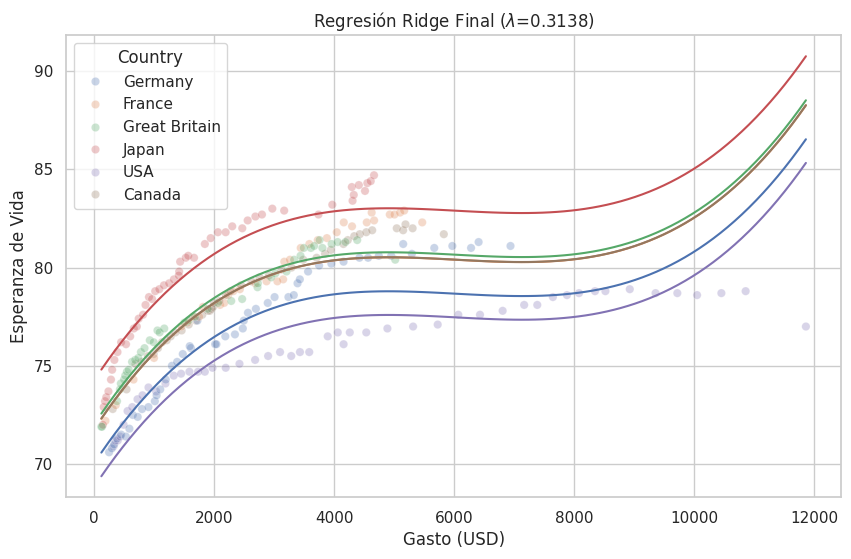

In [60]:
# 5. Graficar la regresión obtenida con el mejor lambda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Spending_USD', y='Life_Expectancy', hue='Country', alpha=0.3)

gasto_range = np.linspace(df['Spending_USD'].min(), df['Spending_USD'].max(), 100)
for pais in df['Country'].unique():
    X_plot = pd.DataFrame({'Country': [pais] * 100, 'Spending_USD': gasto_range})
    y_plot = final_model.predict(X_plot)
    plt.plot(gasto_range, y_plot)

plt.title(f'Regresión Ridge Final ($\lambda$={best_lambda:.4f})')
plt.xlabel('Gasto (USD)')
plt.ylabel('Esperanza de Vida')
plt.show()

## Ítem E